✓ 폰트 파일 발견: DIN_1451_LT_Pro_Engschrift.otf
✓ 폰트 파일 발견: DIN_2014_Bold_Italic.otf
✓ 폰트 파일 발견: DIN_2014_Demi.otf
✓ 폰트 파일 발견: DIN_2014_Extra_Bold_Italic.otf
✓ 폰트 파일 발견: DIN_2014_Extra_Light_Italic.otf
✓ 폰트 파일 발견: DIN_2014_Narrow_Demi.otf
✓ 폰트 파일 발견: DIN_2014_Narrow_Light.otf
✓ 폰트 파일 발견: DIN_2014.otf
✓ 폰트 파일 발견: DIN_Condensed_Light.otf
✓ 폰트 파일 발견: DIN_Condensed_VF.otf
✓ 폰트 파일 발견: DIN_Condensed.otf

총 11개의 DIN 폰트 파일을 찾았습니다.

✓ 등록 성공: DIN 1451 LT Pro Engschrift (DIN_1451_LT_Pro_Engschrift.otf)
✓ 등록 성공: DIN 2014 (DIN_2014_Bold_Italic.otf)
✓ 등록 성공: DIN 2014 (DIN_2014_Demi.otf)
✓ 등록 성공: DIN 2014 (DIN_2014_Extra_Bold_Italic.otf)
✓ 등록 성공: DIN 2014 (DIN_2014_Extra_Light_Italic.otf)
✓ 등록 성공: DIN 2014 Narrow (DIN_2014_Narrow_Demi.otf)
✓ 등록 성공: DIN 2014 Narrow (DIN_2014_Narrow_Light.otf)
✓ 등록 성공: DIN 2014 (DIN_2014.otf)
✓ 등록 성공: DIN Condensed (DIN_Condensed_Light.otf)
✓ 등록 성공: DIN Condensed VF (DIN_Condensed_VF.otf)
✓ 등록 성공: DIN Condensed (DIN_Condensed.otf)

총 11개의 폰트가 등록되었습니다.

matplotlib에서 인식된 DIN 

/tmp/ipykernel_256310/379566279.py:173: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DIN 2014.
  plt.tight_layout()
/root/miniforge3/envs/pyscf2/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DIN 2014.
  fig.canvas.print_figure(bytes_io, **kw)


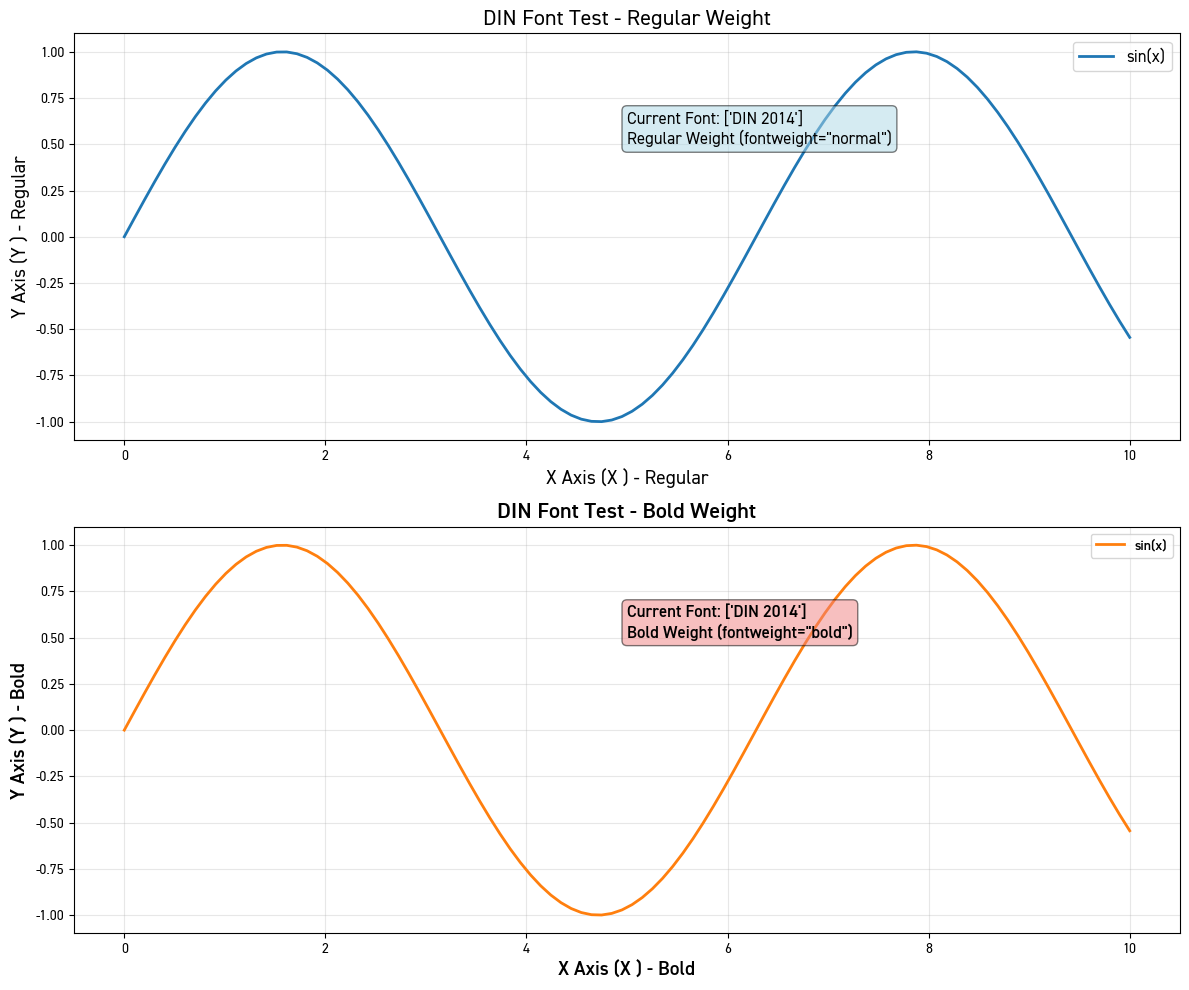


다양한 Font Weight 비교 테스트...
✓ Normal (normal): 테스트 완료
✓ Bold (bold): 테스트 완료
✓ Light (light): 테스트 완료
✓ Heavy (heavy): 테스트 완료
✓ Black (black): 테스트 완료


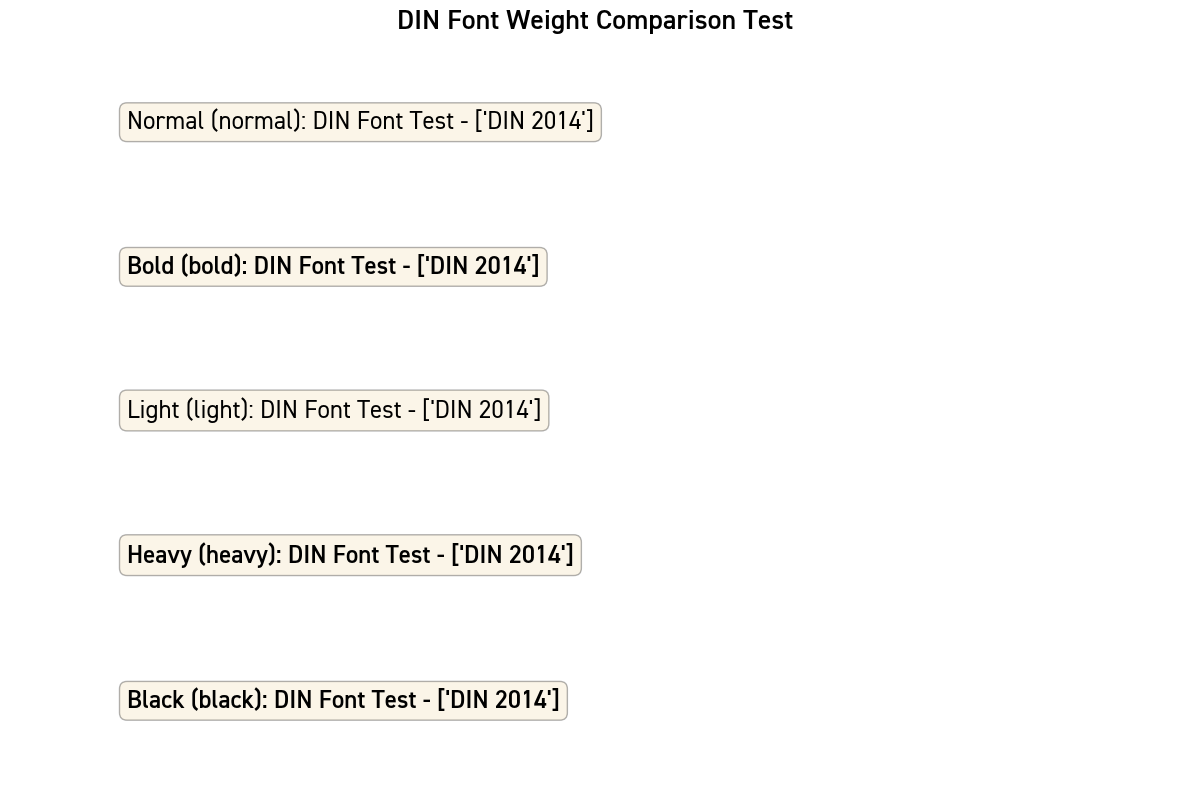


DIN 특정 Weight 직접 테스트...
✓ Condensed (DIN Condensed): 테스트 완료
✓ Regular (DIN 2014): 테스트 완료


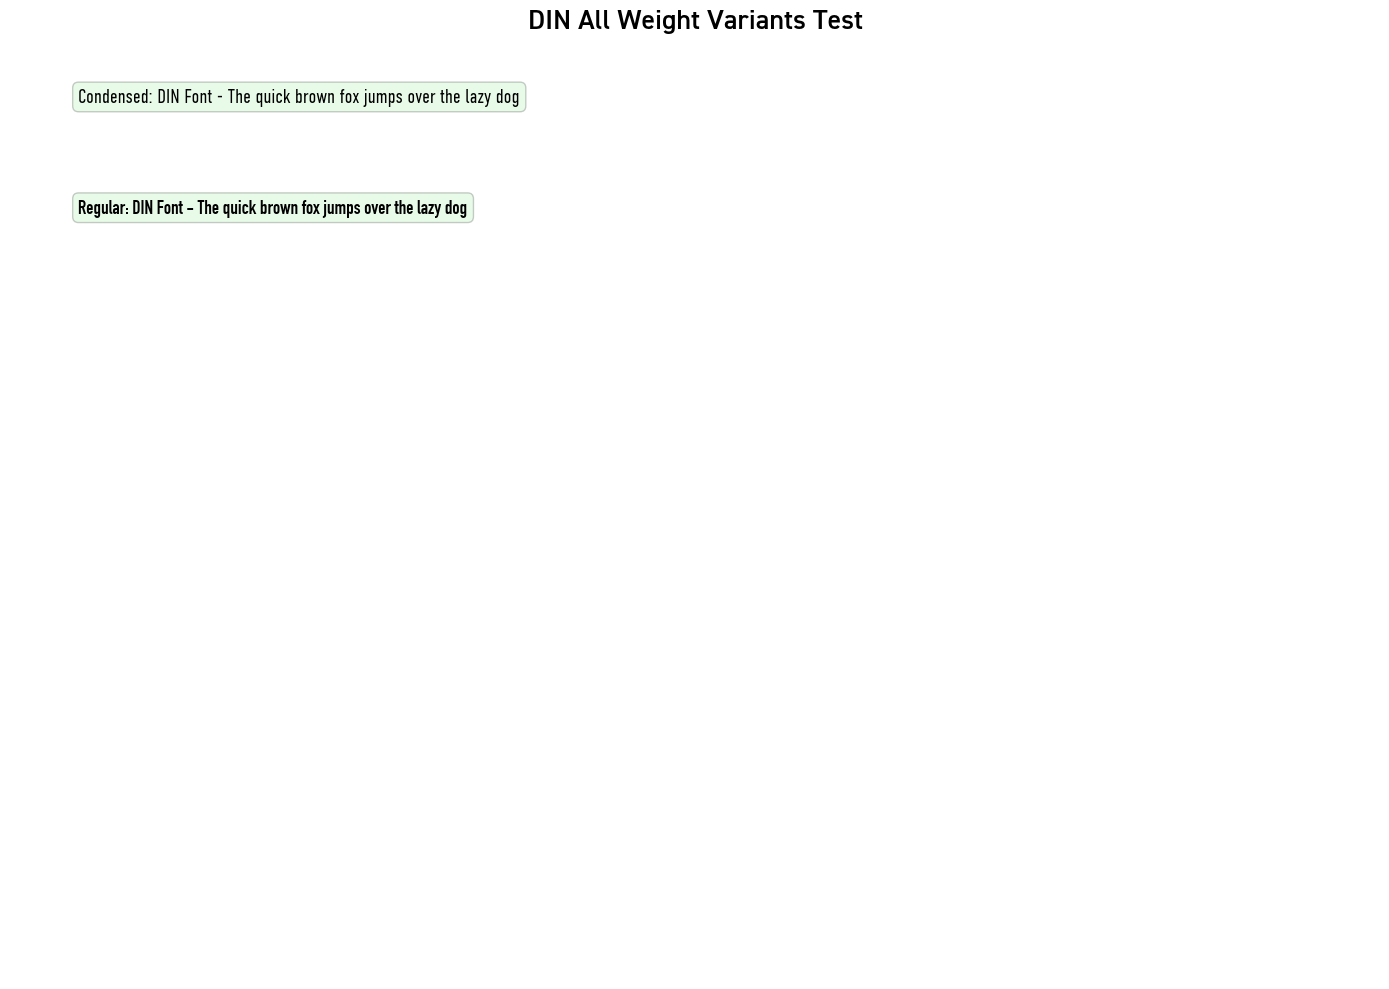


✓ 모든 테스트 플롯이 생성되었습니다.
  현재 사용 중인 폰트: ['DIN 2014']
  Bold 폰트 사용 가능: False


In [2]:
# DIN 폰트 설치 및 설정
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import os
import numpy as np

# DIN 폰트 파일 경로
font_dir = '/root/25DFT/font'

# 폰트 디렉토리에서 모든 DIN 폰트 파일 찾기
font_files = []
if os.path.exists(font_dir):
    for file in os.listdir(font_dir):
        if file.lower().endswith(('.otf', '.ttf', '.ttc')) and 'din' in file.lower():
            font_path = os.path.join(font_dir, file)
            font_files.append(font_path)
            print(f"✓ 폰트 파일 발견: {file}")

print(f"\n총 {len(font_files)}개의 DIN 폰트 파일을 찾았습니다.\n")

# matplotlib에 폰트 직접 등록
registered_fonts = []
for font_path in font_files:
    try:
        # 폰트를 matplotlib에 직접 추가
        fm.fontManager.addfont(font_path)
        # 폰트 정보 가져오기
        font_prop = fm.FontProperties(fname=font_path)
        font_name = font_prop.get_name()
        registered_fonts.append((font_name, font_path))
        print(f"✓ 등록 성공: {font_name} ({os.path.basename(font_path)})")
    except Exception as e:
        print(f"✗ 등록 실패: {os.path.basename(font_path)} - {str(e)}")

# 등록된 폰트 확인
if registered_fonts:
    print(f"\n총 {len(registered_fonts)}개의 폰트가 등록되었습니다.")
    
    # matplotlib에서 인식된 DIN 폰트 확인
    all_fonts = sorted(set([f.name for f in fm.fontManager.ttflist]))
    din_fonts = [f for f in all_fonts if 'din' in f.lower()]
    
    print(f"\nmatplotlib에서 인식된 DIN 폰트:")
    for font in din_fonts:
        print(f"  - {font}")
    
    # DIN 2014 우선 사용, 없으면 다른 DIN 폰트 사용
    din_font_props = [f for f in fm.fontManager.ttflist if 'DIN' in f.name or 'din' in f.name.lower()]
    if din_font_props:
        # DIN 2014 Regular 우선 찾기
        din_2014 = [
            f for f in din_font_props
            if '2014' in f.name
            and 'Bold' not in f.name
            and 'Italic' not in f.name
            and 'Demi' not in f.name
            and 'Narrow' not in f.name
            and 'Extra' not in f.name
        ]
        if din_2014:
            din_font_name = din_2014[0].name
        else:
            print("\n⚠ DIN 2014 폰트를 찾을 수 없습니다. 다른 DIN 폰트를 사용합니다.")
            # DIN 2014가 없으면 일반 DIN-Regular 사용
            din_regular = [
                f for f in din_font_props
                if 'Bold' not in f.name
                and 'Italic' not in f.name
                and 'Condensed' not in f.name
                and 'Exp' not in f.name
                and '2014' not in f.name
            ]
            if din_regular:
                din_font_name = din_regular[0].name
            else:
                # Regular가 없으면 첫 번째 DIN 폰트 사용
                din_font_name = din_font_props[0].name

        plt.rcParams['font.family'] = din_font_name
        plt.rcParams['font.sans-serif'] = [din_font_name] + plt.rcParams['font.sans-serif']
        print(f"\n✓ DIN 폰트를 기본 폰트로 설정했습니다: {din_font_name}")
    else:
        # 등록은 되었지만 이름이 다른 경우
        din_font_name = registered_fonts[0][0]
        plt.rcParams['font.family'] = din_font_name
        plt.rcParams['font.sans-serif'] = [din_font_name] + plt.rcParams['font.sans-serif']
        print(f"\n✓ DIN 폰트를 기본 폰트로 설정했습니다: {din_font_name}")
else:
    # DIN이 없으면 대체 폰트 사용
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    if 'Arial' in available_fonts:
        plt.rcParams['font.family'] = 'Arial'
        print("\n⚠ DIN 폰트를 찾을 수 없습니다. Arial 폰트를 사용합니다.")
    elif 'Helvetica' in available_fonts:
        plt.rcParams['font.family'] = 'Helvetica'
        print("\n⚠ DIN 폰트를 찾을 수 없습니다. Helvetica 폰트를 사용합니다.")
    else:
        plt.rcParams['font.family'] = 'DejaVu Sans'
        print("\n⚠ DIN 폰트를 찾을 수 없습니다. DejaVu Sans 폰트를 사용합니다.")

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호는 유지

# Bold 폰트 확인
print("\n" + "="*50)
print("DIN Bold 폰트 확인 중...")
print("="*50)

# Bold 폰트 파일이 있는지 확인
bold_font_files = [f for f in font_files if 'bold' in os.path.basename(f).lower() and 'italic' not in os.path.basename(f).lower()]
if bold_font_files:
    print(f"✓ Bold 폰트 파일 발견: {[os.path.basename(f) for f in bold_font_files]}")
    bold_available = True
else:
    print("⚠ 별도의 Bold 폰트 파일이 없습니다. (synthetic bold 사용 가능)")
    bold_available = False

# Bold 폰트 이름 확인 (DIN_2014 Bold 우선)
din_font_props = [f for f in fm.fontManager.ttflist if 'DIN' in f.name or 'din' in f.name.lower()]
# DIN_2014 Bold 우선 찾기
din_2014_bold = [f for f in din_font_props if '2014' in f.name and 'Bold' in f.name and 'Italic' not in f.name]
bold_font_names = [f.name for f in din_2014_bold] if din_2014_bold else [f.name for f in din_font_props if 'Bold' in f.name and 'Italic' not in f.name]
if bold_font_names:
    print(f"✓ Bold 폰트 이름: {bold_font_names}")
else:
    print("⚠ Bold 폰트 이름이 인식되지 않았습니다. (fontweight='bold'로 synthetic bold 시도)")
    
# 사용 가능한 모든 DIN weight 확인
print(f"\n사용 가능한 DIN 폰트 weight:")
weight_variants = {}
for font_prop in din_font_props:
    name = font_prop.name
    if 'Italic' not in name:
        if 'Bold' in name:
            weight_variants['Bold'] = name
        elif 'Condensed' in name:
            if 'Bold' in name:
                weight_variants['Condensed Bold'] = name
            else:
                weight_variants['Condensed'] = name
        elif 'Exp' in name:
            if 'Bold' in name:
                weight_variants['Exp Bold'] = name
            else:
                weight_variants['Exp'] = name
        else:
            weight_variants['Regular'] = name
            
for weight, name in sorted(weight_variants.items()):
    print(f"  - {weight}: {name}")

# 테스트 플롯 생성 - Regular vs Bold 비교
print("\n" + "="*50)
print("DIN 폰트 테스트 플롯 생성 중 (Regular & Bold 비교)...")
print("="*50)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 첫 번째 플롯: 기본 테스트
ax1 = axes[0]
x = np.linspace(0, 10, 100)
y = np.sin(x)

ax1.plot(x, y, linewidth=2, label='sin(x)')
ax1.set_xlabel('X Axis (X축) - Regular', fontsize=14)
ax1.set_ylabel('Y Axis (Y축) - Regular', fontsize=14)
ax1.set_title('DIN Font Test - Regular Weight', fontsize=16, fontweight='normal')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=12)

current_font = plt.rcParams['font.family']
ax1.text(5, 0.5, f'Current Font: {current_font}\nRegular Weight (fontweight="normal")', 
        fontsize=12, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# 두 번째 플롯: Bold 테스트
ax2 = axes[1]
ax2.plot(x, y, linewidth=2, label='sin(x)', color='C1')
ax2.set_xlabel('X Axis (X축) - Bold', fontsize=14, fontweight='bold')
ax2.set_ylabel('Y Axis (Y축) - Bold', fontsize=14, fontweight='bold')
ax2.set_title('DIN Font Test - Bold Weight', fontsize=16, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=12, prop={'weight': 'bold'})

# Bold 텍스트 추가
bold_text = f'Current Font: {current_font}\nBold Weight (fontweight="bold")'
ax2.text(5, 0.5, bold_text, 
        fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))

plt.tight_layout()
plt.show()

# 추가 테스트: 다양한 fontweight 비교
print("\n" + "="*50)
print("다양한 Font Weight 비교 테스트...")
print("="*50)

fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

# 다양한 fontweight 테스트
weights = ['normal', 'bold', 'light', 'heavy', 'black']
weight_names = ['Normal', 'Bold', 'Light', 'Heavy', 'Black']
y_positions = np.linspace(0.9, 0.1, len(weights))

test_text = f"DIN Font Test - {current_font}"

for i, (weight, name) in enumerate(zip(weights, weight_names)):
    try:
        ax.text(0.1, y_positions[i], f'{name} ({weight}): {test_text}', 
               fontsize=18, fontweight=weight, 
               transform=ax.transAxes,
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
        print(f"✓ {name} ({weight}): 테스트 완료")
    except Exception as e:
        ax.text(0.1, y_positions[i], f'{name} ({weight}): [ERROR - {str(e)}]', 
               fontsize=18, transform=ax.transAxes,
               bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))
        print(f"✗ {name} ({weight}): 오류 - {str(e)}")

ax.set_title('DIN Font Weight Comparison Test', fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# DIN 특정 weight 직접 테스트
if 'weight_variants' in locals() and weight_variants:
    print("\n" + "="*50)
    print("DIN 특정 Weight 직접 테스트...")
    print("="*50)
    
    # weight 이름과 파일 경로 매핑 생성
    weight_to_file = {}
    for f_path in font_files:
        fname = os.path.basename(f_path).lower()
        if 'italic' not in fname:
            if 'bold' in fname:
                if 'condensed' in fname and 'Condensed Bold' not in weight_to_file:
                    weight_to_file['Condensed Bold'] = f_path
                elif 'exp' in fname and 'Exp Bold' not in weight_to_file:
                    weight_to_file['Exp Bold'] = f_path
                elif 'Bold' not in weight_to_file:
                    weight_to_file['Bold'] = f_path
            elif 'condensed' in fname and 'Condensed' not in weight_to_file:
                weight_to_file['Condensed'] = f_path
            elif 'exp' in fname and 'Exp' not in weight_to_file:
                weight_to_file['Exp'] = f_path
            elif 'Regular' not in weight_to_file:
                weight_to_file['Regular'] = f_path
    
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.axis('off')
    
    y_pos = 0.95
    test_text_base = "DIN Font - The quick brown fox jumps over the lazy dog"
    
    for weight_name, font_name in sorted(weight_variants.items()):
        try:
            # 파일 경로 찾기
            font_path = None
            if weight_name in weight_to_file:
                font_path = weight_to_file[weight_name]
            else:
                # registered_fonts에서 찾기
                for reg_name, reg_path in registered_fonts:
                    if font_name in reg_name:
                        font_path = reg_path
                        break
            
            if font_path and os.path.exists(font_path):
                font_prop = fm.FontProperties(fname=font_path)
                ax.text(0.05, y_pos, f'{weight_name}: {test_text_base}', 
                       fontsize=14, fontproperties=font_prop,
                       transform=ax.transAxes,
                       bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.2))
                print(f"✓ {weight_name} ({font_name}): 테스트 완료")
            else:
                # 폰트 이름으로 직접 사용
                font_prop = fm.FontProperties(family=font_name)
                ax.text(0.05, y_pos, f'{weight_name}: {test_text_base}', 
                       fontsize=14, fontproperties=font_prop,
                       transform=ax.transAxes,
                       bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.2))
                print(f"✓ {weight_name} ({font_name}): 테스트 완료 (이름으로)")
            y_pos -= 0.12
        except Exception as e:
            ax.text(0.05, y_pos, f'{weight_name}: [ERROR - {str(e)}]', 
                   fontsize=14, transform=ax.transAxes,
                   bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))
            print(f"✗ {weight_name}: 오류 - {str(e)}")
            y_pos -= 0.12
    
    ax.set_title('DIN All Weight Variants Test', fontsize=20, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

print(f"\n✓ 모든 테스트 플롯이 생성되었습니다.")
print(f"  현재 사용 중인 폰트: {plt.rcParams['font.family']}")
if 'bold_available' in locals():
    print(f"  Bold 폰트 사용 가능: {bold_available}")

In [3]:
import matplotlib.font_manager as fm
from matplotlib.font_manager import FontProperties
din_font_props = [f for f in fm.fontManager.ttflist if 'DIN' in f.name or 'din' in f.name.lower()]
if din_font_props:
    # DIN_2014 우선 사용
    din_2014 = [f for f in din_font_props if '2014' in f.name and 'Bold' not in f.name and 'Italic' not in f.name and 'Demi' not in f.name and 'Narrow' not in f.name and 'Extra' not in f.name]
    if din_2014:
        din_font_name = din_2014[0].name
    else:
        # DIN_2014가 없으면 DINExp (Expanded) 사용
        din_exp_regular = [f for f in din_font_props if 'Exp' in f.name and 'Bold' not in f.name and 'Italic' not in f.name]
        if din_exp_regular:
            din_font_name = din_exp_regular[0].name
        else:
            # Exp가 없으면 일반 DIN 사용
            din_regular = [f for f in din_font_props if 'Bold' not in f.name and 'Italic' not in f.name and 'Condensed' not in f.name and 'Exp' not in f.name and '2014' not in f.name]
            din_font_name = din_regular[0].name if din_regular else din_font_props[0].name
    
    # Bold 버전 찾기 (DIN_2014 Bold 우선)
    din_2014_bold = [f for f in din_font_props if '2014' in f.name and 'Bold' in f.name and 'Italic' not in f.name]
    if din_2014_bold:
        din_bold_name = din_2014_bold[0].name
    else:
        # DIN_2014 Bold가 없으면 Expanded Bold 사용
        din_exp_bold = [f for f in din_font_props if 'Exp' in f.name and 'Bold' in f.name and 'Italic' not in f.name]
        if din_exp_bold:
            din_bold_name = din_exp_bold[0].name
        else:
            din_bold = [f for f in din_font_props if 'Bold' in f.name and 'Italic' not in f.name and 'Condensed' not in f.name and 'Exp' not in f.name and '2014' not in f.name]
            din_bold_name = din_bold[0].name if din_bold else None
else:
    din_font_name = None
    din_bold_name = None

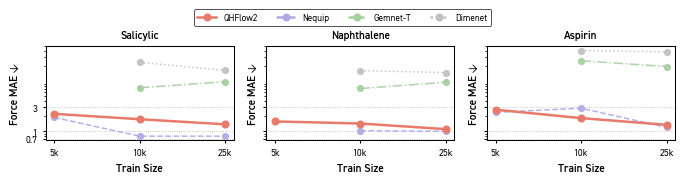

Saved: QHFlow/_asset/md17_datascaling/figures_3panel/force_mae_3panel_20260112-234212.pdf


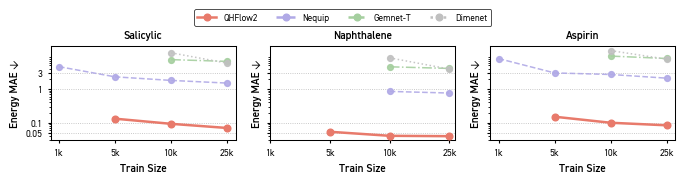

Saved: QHFlow/_asset/md17_datascaling/figures_3panel/energy_mae_3panel_20260112-234213.pdf


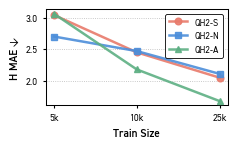

Saved: QHFlow/_asset/md17_datascaling/figures/h_mae_combined_ours_20260112-234213.pdf


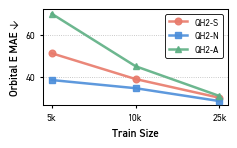

Saved: QHFlow/_asset/md17_datascaling/figures/oe_mae_combined_ours_20260112-234214.pdf


In [8]:
# Plot SCFlow MD17 results (styled like param_new.ipynb)
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.font_manager as fm
import numpy as np
from matplotlib.lines import Line2D
from pathlib import Path
from datetime import datetime

# ---------------------------------------------------------------------------
# Styling helpers borrowed from param_vs_performance/param_new.ipynb
# ---------------------------------------------------------------------------
# Colors: QHFlow2 uses myred from param_new ("#E87A6B")
MODEL_COLORS = {
    "QHFlow2": "#E87A6B",   # our model (from param_new.ipynb)
    "Nequip": "#B0A9E6",    # pale purple
    "Gemnet-T": "#A5CF9F",  # pale green
    "Dimenet": "#C0C0C0",   # light gray
}
MOL_MARKERS = {
    "Sal": "o",
    "Naph": "s",
    "Asp": "^",
}
MODEL_LINESTYLES = {
    "QHFlow2": "-",
    "Nequip": "--",
    "Gemnet-T": "-.",
    "Dimenet": ":",
}
FONT_SIZES = {"label": 8, "tick": 7, "annot": 7}
plt.rcParams["axes.unicode_minus"] = False

MOLECULES = ["Sal", "Naph", "Asp"]
MOL_FULL = {"Sal": "Salicylic", "Naph": "Naphthalene", "Asp": "Aspirin"}
MOL_COLORS = {
    "Sal": "#E87A6B",   # coral
    "Naph": "#4C8EDA",  # blue
    "Asp": "#5DAF83",  # green
}


def setup_axes(ax, xlabel, ylabel, din_font=None, din_bold=None, fs_override=None):
    fs = fs_override or FONT_SIZES
    if din_bold:
        ax.set_xlabel(xlabel, fontsize=fs["label"], fontfamily=din_bold)
        ax.set_ylabel(ylabel, fontsize=fs["label"], fontfamily=din_bold)
    elif din_font:
        ax.set_xlabel(xlabel, fontsize=fs["label"], fontweight="bold", fontfamily=din_font)
        ax.set_ylabel(ylabel, fontsize=fs["label"], fontweight="bold", fontfamily=din_font)
    else:
        ax.set_xlabel(xlabel, fontsize=fs["label"], fontweight="bold")
        ax.set_ylabel(ylabel, fontsize=fs["label"], fontweight="bold")
    ax.tick_params(labelsize=fs["tick"], direction="out", length=2.25)
    ax.grid(True, which="major", axis="y", ls=":", alpha=0.9, linewidth=0.6, zorder=0)
    # 모든 테두리를 보이게 (위/오른쪽 포함)
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(0.75)


def setup_legend(ax, din_font=None, loc="upper right", fs_override=None):
    fs = fs_override or FONT_SIZES
    legend = ax.legend(frameon=True, edgecolor="black", framealpha=1,
                      fontsize=fs["annot"]*0.95, loc=loc)
    legend.get_frame().set_linewidth(0.6)
    if din_font:
        for text in legend.get_texts():
            text.set_fontfamily(din_font)
    return legend


din_font, din_bold = din_font_name, din_bold_name

# ---------------------------------------------------------------------------
# User inputs / Conditions
# ---------------------------------------------------------------------------
# - models_to_plot: 원하는 모델만 남기면 해당 모델만 그립니다.
# - train_sizes_to_plot: None이면 데이터에 '적혀있는 train_size'만 자동 정렬해서 사용합니다.
models_to_plot = ["QHFlow2", "Nequip", "Gemnet-T", "Dimenet"]
train_sizes_to_plot = None  # e.g. ["1k", "5k", "10k", "25k"]


def _train_size_key(x):
    """Sort key for train_size strings like '1k', '25k', '100', etc."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return float("inf")
    s = str(x).strip().lower()
    if s in {"<na>", "nan", "none", ""}:
        return float("inf")
    mult = 1.0
    if s.endswith("k"):
        mult = 1e3
        s = s[:-1]
    elif s.endswith("m"):
        mult = 1e6
        s = s[:-1]
    try:
        return float(s) * mult
    except ValueError:
        return float("inf")


def _resolve_train_sizes(df, train_sizes=None):
    """Return (order, train_pos) for plotting.

    - train_sizes=None: use all train sizes present in df (sorted numerically: 1k < 5k < 10k ...)
    - train_sizes=list: only keep those that exist in df
    """
    ts_series = df["train_size"].dropna().astype("string")
    available = sorted(ts_series.unique().tolist(), key=_train_size_key)
    order = train_sizes if train_sizes is not None else available
    order = [ts for ts in order if ts in set(ts_series.tolist())]
    train_pos = {v: i for i, v in enumerate(order)}
    return order, train_pos


# Manual table (train_size full -> 25k) - EF values updated
rows = [
    # QHFlow2 (ours) per molecule
    {"dataset": "QHFlow2 - Sal", "train_size": "5k", "h_mae": 3.04, "oe_mae": 51.35, "coeff_sim": 99.87, "energy_mae": 0.132, "force_mae": 2.239},
    {"dataset": "QHFlow2 - Sal", "train_size": "10k", "h_mae": 2.45, "oe_mae": 39.15, "coeff_sim": 99.90, "energy_mae": 0.093, "force_mae": 1.747}, 
    {"dataset": "QHFlow2 - Sal", "train_size": "25k", "h_mae": 2.05, "oe_mae": 30.31, "coeff_sim": 99.91, "energy_mae": 0.070, "force_mae": 1.381},
    {"dataset": "QHFlow2 - Naph", "train_size": "5k", "h_mae": 2.70, "oe_mae": 38.69, "coeff_sim": 98.91, "energy_mae": 0.054, "force_mae": 1.578},
    {"dataset": "QHFlow2 - Naph", "train_size": "10k", "h_mae": 2.47, "oe_mae": 34.83, "coeff_sim": 99.09, "energy_mae": 0.041, "force_mae": 1.434},
    {"dataset": "QHFlow2 - Naph", "train_size": "25k", "h_mae": 2.11, "oe_mae": 28.74, "coeff_sim": 99.27, "energy_mae": 0.040, "force_mae": 1.106}, 
    {"dataset": "QHFlow2 - Asp", "train_size": "5k", "h_mae": 3.06, "oe_mae": 70.03, "coeff_sim": 99.78, "energy_mae": 0.151, "force_mae": 2.711},
    {"dataset": "QHFlow2 - Asp", "train_size": "10k", "h_mae": 2.18, "oe_mae": 45.21, "coeff_sim": 99.86, "energy_mae": 0.100, "force_mae": 1.838},
    {"dataset": "QHFlow2 - Asp", "train_size": "25k", "h_mae": 1.68, "oe_mae": 31.14, "coeff_sim": 99.90, "energy_mae": 0.084, "force_mae": 1.350},
    # Baselines (energy/force for all train sizes, per molecule)
    {"dataset": "Nequip - Sal", "train_size": "1k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 4.6, "force_mae": 1.2},
    {"dataset": "Nequip - Sal", "train_size": "5k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 2.3, "force_mae": 1.9},
    {"dataset": "Nequip - Sal", "train_size": "10k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 1.8, "force_mae": 0.8},
    {"dataset": "Nequip - Sal", "train_size": "25k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 1.5, "force_mae": 0.8},
    # {"dataset": "Nequip - Naph", "train_size": "5k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 0.83, "force_mae": 0.72},
    {"dataset": "Nequip - Naph", "train_size": "10k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 0.85, "force_mae": 1.03},
    {"dataset": "Nequip - Naph", "train_size": "25k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 0.76, "force_mae": 1.00},
    {"dataset": "Nequip - Asp", "train_size": "1k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 8, "force_mae": 3},
    {"dataset": "Nequip - Asp", "train_size": "5k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 3.0, "force_mae": 2.4},
    {"dataset": "Nequip - Asp", "train_size": "10k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 2.7, "force_mae": 2.9},
    {"dataset": "Nequip - Asp", "train_size": "25k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 2.1, "force_mae": 1.2},
    # {"dataset": "Gemnet-T - Sal", "train_size": "5k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 1.8, "force_mae": 1},
    {"dataset": "Gemnet-T - Sal", "train_size": "10k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan,"energy_mae": 6.2, "force_mae": 6.2},
    {"dataset": "Gemnet-T - Sal", "train_size": "25k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 5.5, "force_mae": 8.2}, #ALMOST DONE
    # {"dataset": "Gemnet-T - Naph", "train_size": "5k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan,"energy_mae": 0.83, "force_mae": 0.72},
    {"dataset": "Gemnet-T - Naph", "train_size": "10k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 3.8, "force_mae": 6},
    {"dataset": "Gemnet-T - Naph", "train_size": "25k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 3.4, "force_mae": 8}, #ALMOST DONE
    # {"dataset": "Gemnet-T - Asp", "train_size": "5k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 2.8, "force_mae": 2.4},
    {"dataset": "Gemnet-T - Asp", "train_size": "10k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 7.9, "force_mae": 21.5},
    {"dataset": "Gemnet-T - Asp", "train_size": "25k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 6.7, "force_mae": 16.5},
    # {"dataset": "Dimenet - Sal", "train_size": "5k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 1.8, "force_mae": 1},
    {"dataset": "Dimenet - Sal", "train_size": "10k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae":  7.9, "force_mae": 16},
    {"dataset": "Dimenet - Sal", "train_size": "25k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 3.9, "force_mae": 11},
    # {"dataset": "Dimenet - Naph", "train_size": "5k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan,"energy_mae": 0.83, "force_mae": 0.72},
    {"dataset": "Dimenet - Naph", "train_size": "10k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 5.6, "force_mae": 10.9},
    {"dataset": "Dimenet - Naph", "train_size": "25k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan,"energy_mae": 2.6, "force_mae": 10},
    # {"dataset": "Dimenet - Asp", "train_size": "5k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 2.8, "force_mae": 2.4},
    {"dataset": "Dimenet - Asp", "train_size": "10k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 9.2, "force_mae":  27.5},
    {"dataset": "Dimenet - Asp", "train_size": "25k", "h_mae": np.nan, "oe_mae": np.nan, "coeff_sim": np.nan, "energy_mae": 5.1, "force_mae": 26},
]

# ---------------------------------------------------------------------------
# Build dataframe
# - keep ONLY rows with a valid train_size ("train size가 적혀있는 데이터")
# - do NOT pre-filter by a specific train-size list here (each plot function can decide)
# ---------------------------------------------------------------------------
_df = pd.DataFrame(rows)
_df["train_size"] = _df["train_size"].astype("string")
_df = _df.dropna(subset=["train_size"]).copy()

# Temporary scaling for Gemnet-T and Dimenet (set to 1.0 later)
SCALE_FACTORS = {"Gemnet-T": 1.2, "Dimenet": 1.5}
for model, factor in SCALE_FACTORS.items():
    mask = _df["dataset"].str.startswith(f"{model} -")
    _df.loc[mask, ["energy_mae", "force_mae"]] = _df.loc[mask, ["energy_mae", "force_mae"]] * factor

metrics = ["h_mae", "oe_mae", "energy_mae", "force_mae"]
labels = {
    "h_mae": "Hamiltonian MAE",
    "oe_mae": "Orbital Energy MAE",
    "energy_mae": "Energy MAE",
    "force_mae": "Force MAE",
}
datasets_all = [
    "QHFlow2 - Sal", "QHFlow2 - Naph", "QHFlow2 - Asp",
    "Nequip - Sal", "Nequip - Naph", "Nequip - Asp",
    "Gemnet-T - Sal", "Gemnet-T - Naph", "Gemnet-T - Asp",
    "Dimenet - Sal", "Dimenet - Naph", "Dimenet - Asp",
]
datasets_ours = ["QHFlow2 - Sal", "QHFlow2 - Naph", "QHFlow2 - Asp"]
label_short = {
    # QHFlow2 (ours) per molecule
    "QHFlow2 - Sal": "QH2-S",
    "QHFlow2 - Naph": "QH2-N",
    "QHFlow2 - Asp": "QH2-A",
    # Baseline models
    "Nequip - Sal": "Nq-S",
    "Nequip - Naph": "Nq-N",
    "Nequip - Asp": "Nq-A",
    "Gemnet-T - Sal": "GmT-S",
    "Gemnet-T - Naph": "GmT-N",
    "Gemnet-T - Asp": "GmT-A",
    "Dimenet - Sal": "Dm-S",
    "Dimenet - Naph": "Dm-N",
    "Dimenet - Asp": "Dm-A",
}

# 출력 폴더 및 타임스탬프 설정
out_dir = Path("QHFlow/_asset/md17_datascaling/figures")
out_dir.mkdir(parents=True, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")

# 통일된 폰트 설정 (가능하면 DIN)
plt.rcParams["axes.unicode_minus"] = False
if din_font:
    plt.rcParams["font.family"] = din_font

# 3-panel per molecule helper
mols = MOLECULES
models_default = models_to_plot


def plot_3panel(
    _df,
    metric,
    ylabel,
    models=None,
    train_sizes=None,
    out_dir="QHFlow/_asset/md17_datascaling/figures_3panel",
    ratio=1.05,
    din_font=None,
    y_major_ticks=None,
    colors_override=None,
):
    models = models or models_default
    colors_override = colors_override or {}

    # train_sizes: per-function override (if None, use all train sizes present)
    order_local, train_pos_local = _resolve_train_sizes(
        _df,
        train_sizes=(train_sizes_to_plot if train_sizes is None else train_sizes),
    )

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    ts = datetime.now().strftime("%Y%m%d-%H%M%S")

    fig, axes = plt.subplots(1, 3, figsize=(6.6 * ratio, 1.55 * ratio), sharey=True)

    for j, mol in enumerate(mols):
        ax = axes[j]
        for mdl in models:
            ds = f"{mdl} - {mol}"
            sub = _df[_df["dataset"] == ds].copy()
            sub["train_size"] = sub["train_size"].astype("string")
            sub = sub[sub["train_size"].isin(order_local)].copy()

            # stable ordering by train size
            sub["_ts_cat"] = pd.Categorical(sub["train_size"], categories=order_local, ordered=True)
            sub = sub.sort_values("_ts_cat")

            xs = [train_pos_local[str(t)] for t in sub["train_size"].astype(str)]
            ys = sub[metric].tolist()
            if len(xs) == 0:
                continue
            is_ours = mdl == "QHFlow2"
            color = colors_override.get(mdl, MODEL_COLORS.get(mdl, "black"))
            ax.plot(
                xs,
                ys,
                color=color,
                linestyle=MODEL_LINESTYLES.get(mdl, "-"),
                marker="o",
                fillstyle="full",
                linewidth=1.8 if is_ours else 1.1,
                markersize=4.8 if is_ours else 4.2,
                alpha=1.0 if is_ours else 0.9,
                zorder=3 if is_ours else 2,
                label=mdl if j == 0 else None,
            )

        if metric in ("energy_mae", "force_mae"):
            ax.set_yscale("log")
            log_loc_y = ticker.LogLocator(base=10)
            log_minor_y = ticker.LogLocator(base=10, subs=np.arange(2, 10) * 0.1)
            ax.yaxis.set_major_locator(ticker.FixedLocator(y_major_ticks) if y_major_ticks else log_loc_y)
            ax.yaxis.set_minor_locator(log_minor_y)
            ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:.2g}" if y > 0 else ""))
            ax.yaxis.set_minor_formatter(ticker.NullFormatter())
            ax.tick_params(which="major", length=2.25)
            ax.tick_params(which="minor", length=1.25)

        ax.set_title(MOL_FULL.get(mol, mol), fontsize=FONT_SIZES["label"], fontweight="bold", fontfamily=din_font)
        ax.set_xticks(list(train_pos_local.values()), order_local)
        setup_axes(ax, "Train Size", ylabel, din_font=din_font, din_bold=None)

    # 글로벌 레전드 (모델 색상만 간결히)
    handles = [
        Line2D([0],[0], color=colors_override.get(m, MODEL_COLORS.get(m, "black")), lw=1.8, marker="o",
               markersize=4.8, linestyle=MODEL_LINESTYLES.get(m, "-"), label=m)
        for m in models
    ]
    leg = fig.legend(
        handles=handles, ncol=min(len(handles), 4), frameon=True, edgecolor="black",
        fontsize=FONT_SIZES["annot"]*0.95,
        loc="upper center", bbox_to_anchor=(0.5, 1.12)
    )
    leg.get_frame().set_linewidth(0.6)

    plt.tight_layout(pad=1.0, rect=[0, 0, 1, 1.05])
    fname = out_dir / f"{metric}_3panel_{ts}.pdf"
    fig.savefig(fname, dpi=600, bbox_inches="tight", pad_inches=0.05)
    plt.show()
    print(f"Saved: {fname}")
    return fname


def plot_combined_ours(
    _df,
    metric,
    ylabel,
    train_sizes=None,
    ratio=1.05,
    din_font=None,
    font_sizes_override=None,
    colors_override=None,
):
    """Plot our model (QHFlow2) across all molecules on one axis.

    font_sizes_override: optional dict with keys label/tick/annot to override FONT_SIZES.
    colors_override: optional dict to override per-molecule color (keys use mol short e.g., Sal/Naph/Asp).
    train_sizes: per-function override for x-axis train sizes.
    """
    colors_override = colors_override or {}

    order_local, train_pos_local = _resolve_train_sizes(
        _df,
        train_sizes=(train_sizes_to_plot if train_sizes is None else train_sizes),
    )

    ts = datetime.now().strftime("%Y%m%d-%H%M%S")
    fig, ax = plt.subplots(1, 1, figsize=(2.3 * ratio, 1.45 * ratio))

    for mol in mols:
        ds = f"QHFlow2 - {mol}"
        sub = _df[_df["dataset"] == ds].copy()
        sub["train_size"] = sub["train_size"].astype("string")
        sub = sub[sub["train_size"].isin(order_local)].copy()
        sub["_ts_cat"] = pd.Categorical(sub["train_size"], categories=order_local, ordered=True)
        sub = sub.sort_values("_ts_cat")

        xs = [train_pos_local[str(t)] for t in sub["train_size"].astype(str)]
        ys = sub[metric].tolist()
        if len(xs) == 0:
            continue
        color = colors_override.get(mol, MOL_COLORS.get(mol, MODEL_COLORS.get("QHFlow2", "black")))
        ax.plot(
            xs,
            ys,
            color=color,
            linestyle="-",
            marker=MOL_MARKERS.get(mol, "o"),
            linewidth=1.8,
            markersize=4.8,
            alpha=0.9,
            label=label_short.get(ds, mol),
            zorder=3,
        )

    # 로그 축 + 포매터 (y only)
    ax.tick_params(
        direction="out",
        which="both",
        top=False,
        right=False,
        labelsize=(font_sizes_override or FONT_SIZES)["tick"],
        length=3.0,
    )
    ax.tick_params(which="minor", length=1.25, direction="out", top=False, right=False)
    ax.tick_params(which="major", length=2.25, direction="out", top=False, right=False)

    # ax.set_title("QHFlow2 (ours)", fontsize=FONT_SIZES["label"], fontweight="bold",
    #              fontfamily=din_font if din_font else None)
    ax.set_xticks(list(train_pos_local.values()), order_local)
    setup_axes(ax, "Train Size", ylabel, din_font=din_font, din_bold=None, fs_override=font_sizes_override)
    setup_legend(ax, din_font=din_font, loc="upper right", fs_override=font_sizes_override)

    plt.tight_layout(pad=0.85)
    fname = out_dir / f"{metric}_combined_ours_{ts}.pdf"
    fig.savefig(fname, dpi=600, bbox_inches="tight", pad_inches=0.05)
    plt.show()
    print(f"Saved: {fname}")
    return fname


# 실행 예시
Force_y_ticks = [0.7, 1, 3]
plot_3panel(
    _df,
    "force_mae",
    "Force MAE ↓",
    models=models_to_plot,
    train_sizes=["5k", "10k", "25k"],  # <- 함수별 train size 조건
    din_font=din_font,
    y_major_ticks=Force_y_ticks,
)

Energy_y_ticks = [0.05, 0.1, 1, 3]
plot_3panel(
    _df,
    "energy_mae",
    "Energy MAE ↓",
    models=models_to_plot,
    train_sizes=None,  # <- None이면 데이터에 존재하는 train size 전부 자동 사용 (예: 1k 포함)
    din_font=din_font,
    y_major_ticks=Energy_y_ticks,
)

# Hamiltonian / Orbital Energy: 우리 모델(QHFlow2)만 값이 있어서, 선택된 모델에 QHFlow2가 있을 때만 그림
if "QHFlow2" in models_to_plot:
    NEW_FONT_SIZES = {"label": 8, "tick": 7, "annot": 7}
    plot_combined_ours(
        _df,
        "h_mae",
        "H MAE ↓",
        train_sizes=["5k", "10k", "25k"],  # <- 함수별 train size 조건
        din_font=din_font,
        font_sizes_override=NEW_FONT_SIZES,
    )
    plot_combined_ours(
        _df,
        "oe_mae",
        "Orbital E MAE ↓",
        train_sizes=["5k", "10k", "25k"],  # <- 함수별 train size 조건
        din_font=din_font,
        font_sizes_override=NEW_FONT_SIZES,
    )

# _df